# Customer Support Ticket Analytics System
**Input:** `NLP_enriched_tickets.csv` (200,000 rows)  
**Dashboard Pages:**
- **Page 1** — Executive Overview (KPIs + Volume Trends)
- **Page 2** — SLA & Response Time Analysis
- **Page 3** — Escalation & Risk Analysis
- **Page 4** — Category & Channel Performance

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ──────────────────────────────────────────────
BG        = '#0F1117'   # page background
PANEL     = '#1A1D2E'   # chart panel
ACCENT1   = '#7B68EE'   # purple  – primary
ACCENT2   = '#00D4FF'   # cyan    – secondary
ACCENT3   = '#FF6B6B'   # red     – alert / breach
ACCENT4   = '#51CF66'   # green   – good / met
ACCENT5   = '#FFD93D'   # amber   – warning
TEXT      = '#E8E8F0'   # primary text
SUBTEXT   = '#8888AA'   # secondary text
GRID      = '#2A2D3E'   # grid lines

# ── Matplotlib global style ─────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : PANEL,
    'axes.edgecolor'    : GRID,
    'axes.labelcolor'   : TEXT,
    'axes.titlecolor'   : TEXT,
    'axes.titlesize'    : 11,
    'axes.labelsize'    : 9,
    'xtick.color'       : SUBTEXT,
    'ytick.color'       : SUBTEXT,
    'xtick.labelsize'   : 8,
    'ytick.labelsize'   : 8,
    'grid.color'        : GRID,
    'grid.linewidth'    : 0.6,
    'text.color'        : TEXT,
    'legend.facecolor'  : PANEL,
    'legend.edgecolor'  : GRID,
    'legend.labelcolor' : TEXT,
    'legend.fontsize'   : 8,
    'figure.dpi'        : 130,
})

print('Setup complete ✓')

Setup complete ✓


---
## Load & Prepare Data

In [3]:
df = pd.read_csv('C:/Users/Tarun/OneDrive/Desktop/Project 3/Data Sets/NLP_enriched_tickets.csv',
                 parse_dates=['ticket_created_date', 'ticket_resolved_date'])

# ── Derived columns ─────────────────────────────────────────────
df['year_month']      = df['ticket_created_date'].dt.to_period('M')
df['complexity_bucket'] = pd.cut(
    df['issue_complexity_score'],
    bins=[0,3,6,10], labels=['Low (1-3)', 'Mid (4-6)', 'High (7-10)']
)

# Risk score (0-3)
p95_response   = df['first_response_time_hours'].quantile(0.95)
p95_resolution = df['resolution_time_hours'].quantile(0.95)
df['response_outlier']   = df['first_response_time_hours'] > p95_response
df['resolution_outlier'] = df['resolution_time_hours']     > p95_resolution
df['risk_score'] = (
    df['sla_breached'].astype(int) +
    df['escalated'].astype(int) +
    df['response_outlier'].astype(int)
)
df['risk_label'] = df['risk_score'].map({0:'Low',1:'Medium',2:'High',3:'Critical'})

# Resolved-only subset
df_res = df[df['status'].isin(['Closed','Resolved'])].copy()

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'Date range: {df["ticket_created_date"].min().date()} → {df["ticket_created_date"].max().date()}')

Rows: 200,000  |  Columns: 46
Date range: 2022-01-01 → 2024-12-31


---
## Helper Functions

In [4]:
def style_ax(ax, title='', xlabel='', ylabel='', grid_axis='x'):
    """Apply consistent dark styling to an axis."""
    ax.set_title(title, color=TEXT, fontsize=11, pad=8, fontweight='bold')
    ax.set_xlabel(xlabel, color=SUBTEXT, fontsize=8)
    ax.set_ylabel(ylabel, color=SUBTEXT, fontsize=8)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.6, linestyle='--')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color(GRID)
    return ax


def kpi_card(ax, value, label, color=ACCENT1, sub=None):
    """Draw a KPI card on a given axis."""
    ax.set_facecolor(PANEL)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    # Coloured top bar
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.05, 0.85), 0.9, 0.06,
        boxstyle='round,pad=0.01', color=color, zorder=3
    ))
    ax.text(0.5, 0.58, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.30, label, ha='center', va='center',
            fontsize=9, color=SUBTEXT)
    if sub:
        ax.text(0.5, 0.12, sub, ha='center', va='center',
                fontsize=7.5, color=SUBTEXT, style='italic')


def bar_h(ax, series, title, color=ACCENT1, fmt=None, avg_line=None):
    """Horizontal bar chart with optional avg reference line."""
    series = series.sort_values()
    colors = [ACCENT3 if v > (avg_line or series.mean()) else color for v in series.values]
    ax.barh(series.index, series.values, color=colors, edgecolor=BG, height=0.65)
    if avg_line is not None:
        ax.axvline(avg_line, color=ACCENT5, linestyle='--', linewidth=1.2, label=f'Avg {avg_line:.1f}')
        ax.legend(fontsize=7)
    for i, v in enumerate(series.values):
        label_str = fmt(v) if fmt else f'{v:.1f}'
        ax.text(v + series.values.max()*0.01, i, label_str,
                va='center', fontsize=7.5, color=TEXT)
    style_ax(ax, title=title, grid_axis='x')


print('Helpers ready ✓')

Helpers ready ✓


---
## PAGE 1 — Executive Overview

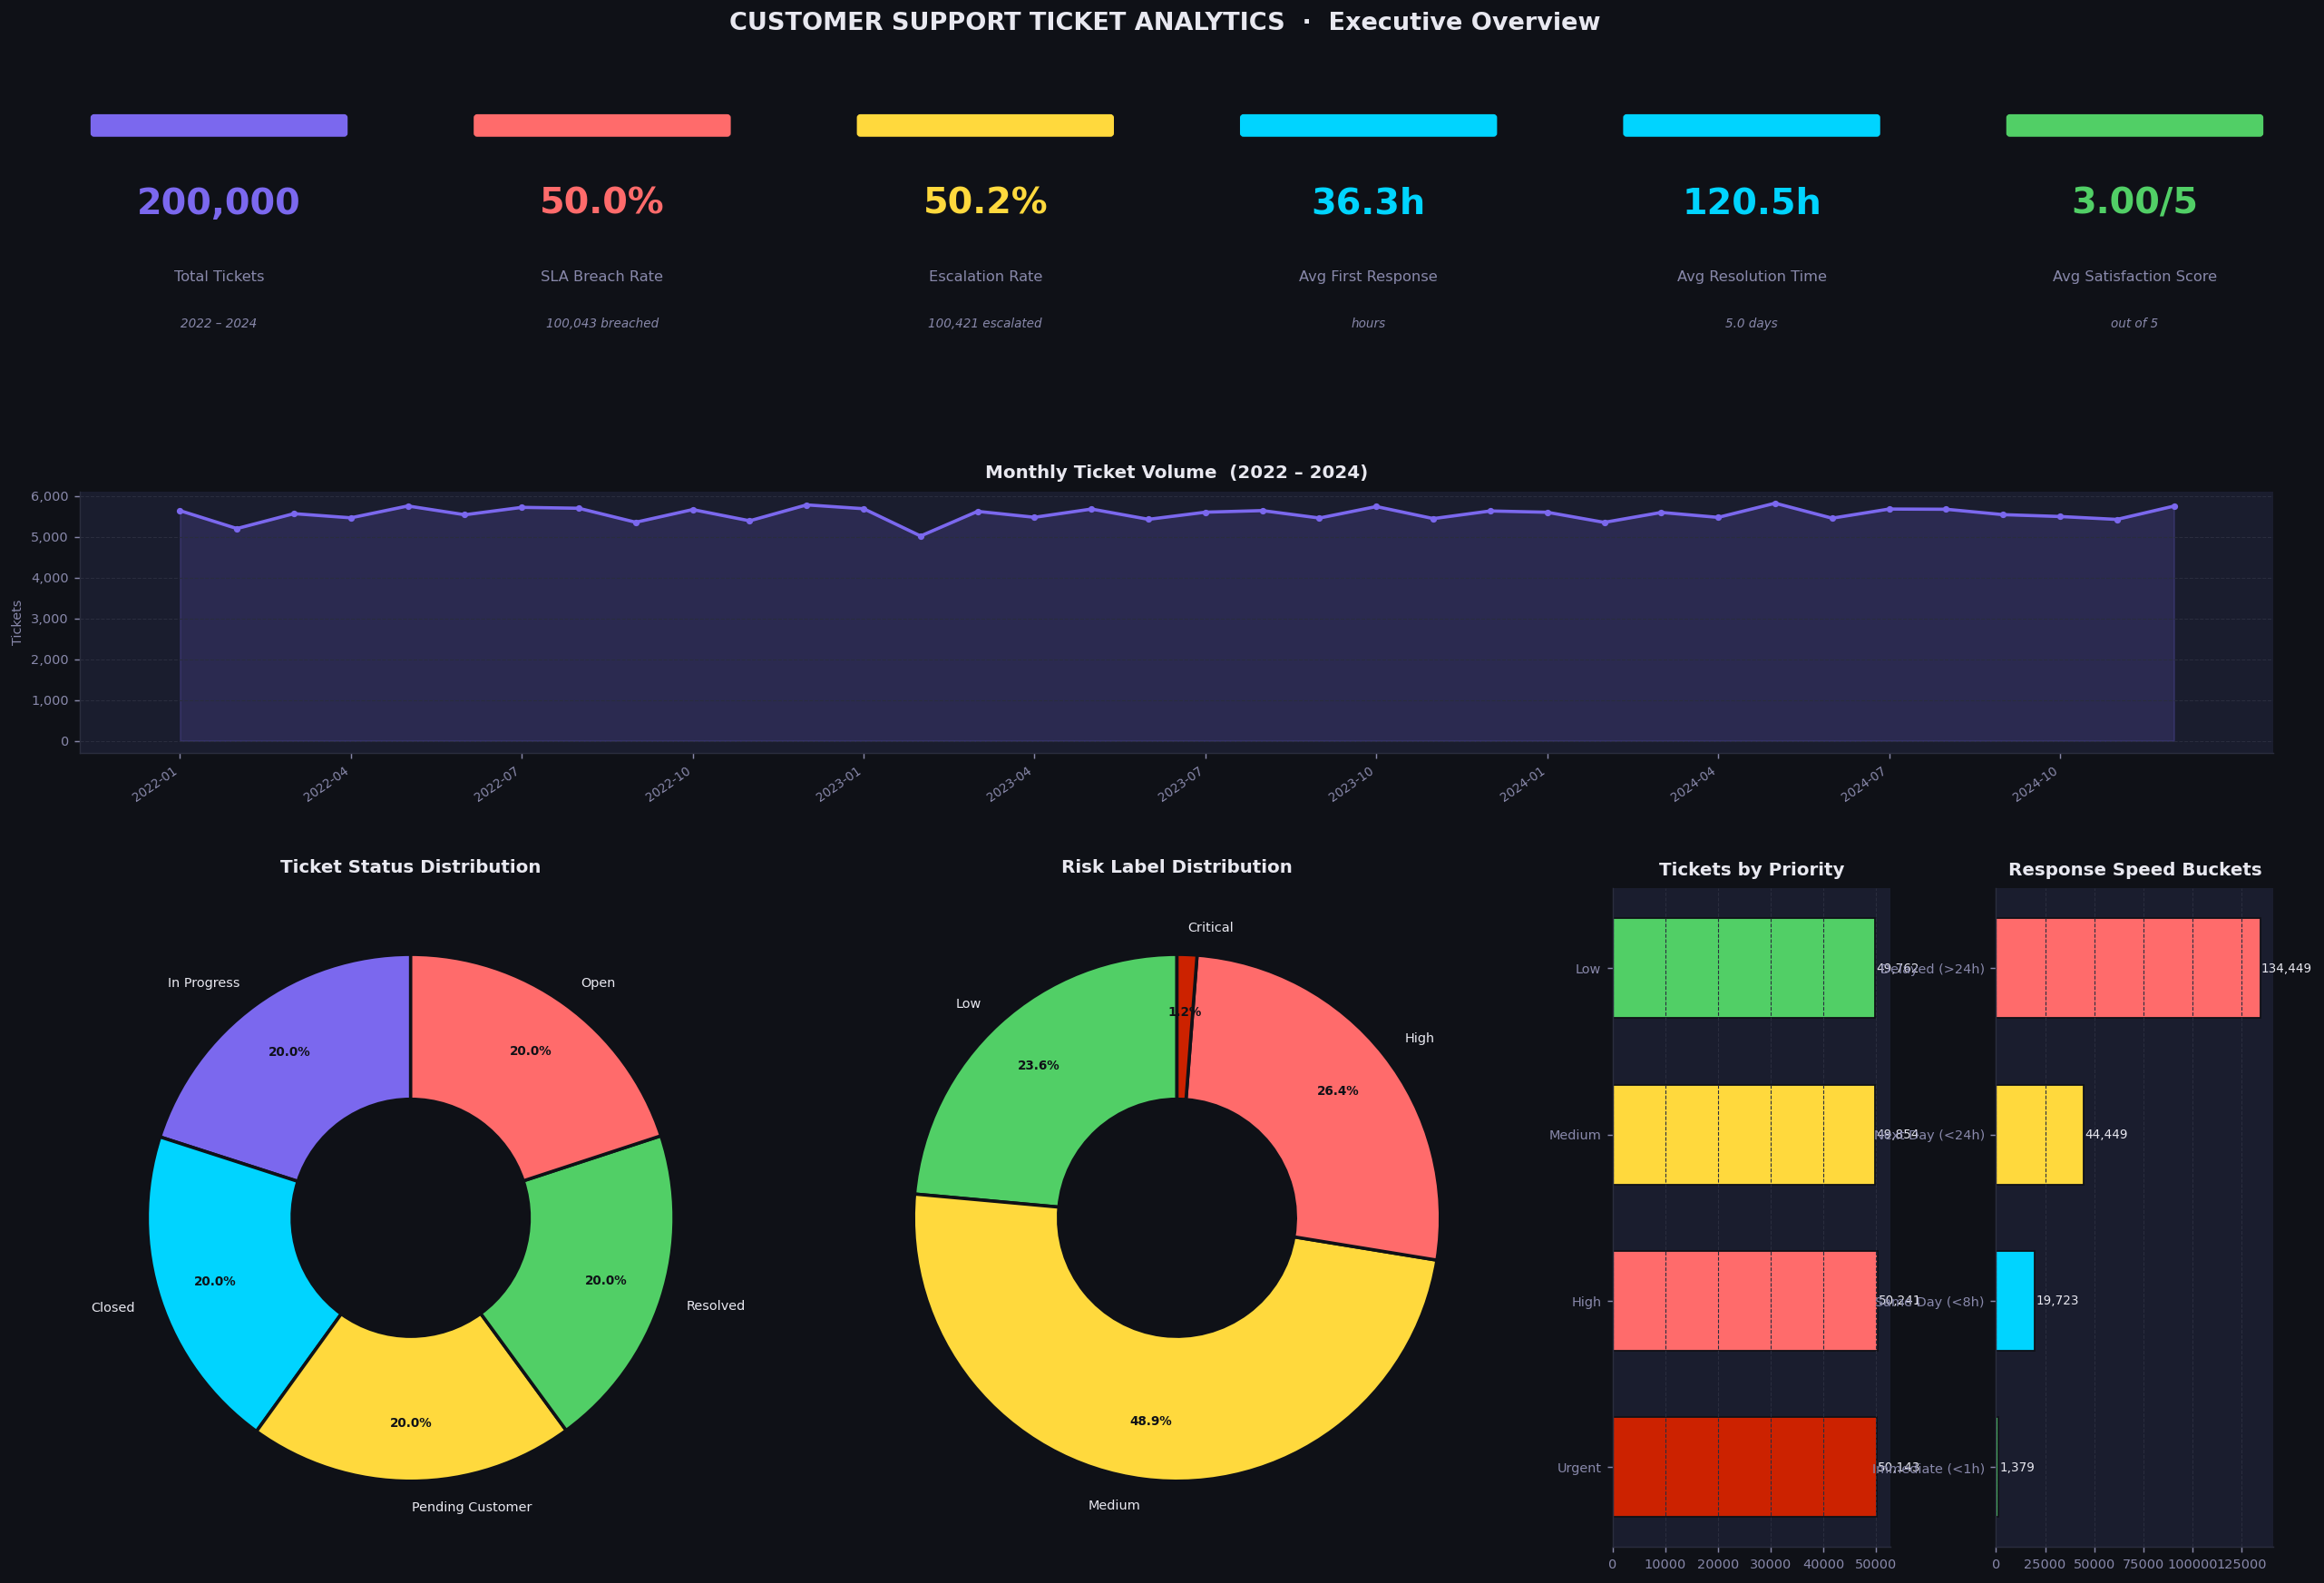

Page 1 saved ✓


In [6]:
# ── Pre-compute ─────────────────────────────────────────────────
total_tickets   = len(df)
sla_breach_rate = df['sla_breached'].mean()
escalation_rate = df['escalated'].mean()
avg_response    = df['first_response_time_hours'].mean()
avg_resolution  = df['resolution_time_hours'].mean()
avg_satisfaction= df['customer_satisfaction_score'].mean()
critical_tickets= (df['risk_label']=='Critical').sum()

monthly_vol = df.groupby('year_month').size().reset_index(name='count')
monthly_vol['ym_str'] = monthly_vol['year_month'].astype(str)

status_dist  = df['status'].value_counts()
risk_dist    = df['risk_label'].value_counts().reindex(['Low','Medium','High','Critical'])
priority_vol = df['priority'].value_counts().reindex(['Urgent','High','Medium','Low'])

# ── Layout ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('CUSTOMER SUPPORT TICKET ANALYTICS  ·  Executive Overview',
             fontsize=15, fontweight='bold', color=TEXT, y=0.98)

gs = gridspec.GridSpec(
    4, 6,
    figure=fig,
    hspace=0.52, wspace=0.38,
    top=0.93, bottom=0.05, left=0.04, right=0.97
)

# ── Row 0: KPI Cards ────────────────────────────────────────────
kpi_data = [
    (f'{total_tickets:,}',    'Total Tickets',              ACCENT1, '2022 – 2024'),
    (f'{sla_breach_rate:.1%}','SLA Breach Rate',            ACCENT3, f'{int(sla_breach_rate*total_tickets):,} breached'),
    (f'{escalation_rate:.1%}','Escalation Rate',            ACCENT5, f'{int(escalation_rate*total_tickets):,} escalated'),
    (f'{avg_response:.1f}h',  'Avg First Response',         ACCENT2, 'hours'),
    (f'{avg_resolution:.1f}h','Avg Resolution Time',        ACCENT2, f'{avg_resolution/24:.1f} days'),
    (f'{avg_satisfaction:.2f}/5','Avg Satisfaction Score',  ACCENT4, 'out of 5'),
]
for col, (val, lbl, col_c, sub) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, col])
    kpi_card(ax, val, lbl, color=col_c, sub=sub)

# ── Row 1: Monthly Volume (full width) ──────────────────────────
ax_vol = fig.add_subplot(gs[1, :])
x = range(len(monthly_vol))
ax_vol.fill_between(x, monthly_vol['count'], alpha=0.18, color=ACCENT1)
ax_vol.plot(x, monthly_vol['count'], color=ACCENT1, linewidth=2, marker='o', markersize=3)
step = max(1, len(monthly_vol)//12)
ax_vol.set_xticks(list(x)[::step])
ax_vol.set_xticklabels(monthly_vol['ym_str'].iloc[::step], rotation=35, ha='right', fontsize=7.5)
ax_vol.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
style_ax(ax_vol, title='Monthly Ticket Volume  (2022 – 2024)', ylabel='Tickets', grid_axis='y')

# ── Row 2-3: Four bottom charts ─────────────────────────────────
ax_status  = fig.add_subplot(gs[2:, 0:2])
ax_risk    = fig.add_subplot(gs[2:, 2:4])
ax_prio    = fig.add_subplot(gs[2:, 4])
ax_speed   = fig.add_subplot(gs[2:, 5])

# Status donut
wedge_colors = [ACCENT1, ACCENT2, ACCENT5, ACCENT4, ACCENT3]
wedges, texts, autotexts = ax_status.pie(
    status_dist.values, labels=status_dist.index,
    colors=wedge_colors[:len(status_dist)],
    autopct='%1.1f%%', pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    startangle=90
)
for t in texts:    t.set_color(TEXT);    t.set_fontsize(8)
for t in autotexts:t.set_color(BG);     t.set_fontsize(7.5); t.set_fontweight('bold')
ax_status.set_title('Ticket Status Distribution', color=TEXT, fontsize=11, fontweight='bold', pad=10)
ax_status.set_facecolor(PANEL)

# Risk donut
risk_colors = [ACCENT4, ACCENT5, ACCENT3, '#CC2200']
valid_risk = risk_dist.dropna()
wedges2, texts2, autotexts2 = ax_risk.pie(
    valid_risk.values, labels=valid_risk.index,
    colors=risk_colors[:len(valid_risk)],
    autopct='%1.1f%%', pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    startangle=90
)
for t in texts2:    t.set_color(TEXT);    t.set_fontsize(8)
for t in autotexts2:t.set_color(BG);     t.set_fontsize(7.5); t.set_fontweight('bold')
ax_risk.set_title('Risk Label Distribution', color=TEXT, fontsize=11, fontweight='bold', pad=10)
ax_risk.set_facecolor(PANEL)

# Priority bar
prio_colors = ['#CC2200', ACCENT3, ACCENT5, ACCENT4]
ax_prio.barh(priority_vol.index, priority_vol.values,
             color=prio_colors[:len(priority_vol)], edgecolor=BG, height=0.6)
for i, v in enumerate(priority_vol.values):
    ax_prio.text(v + 200, i, f'{v:,}', va='center', fontsize=7.5, color=TEXT)
style_ax(ax_prio, title='Tickets by Priority', grid_axis='x')

# Speed bucket bar
bucket_order  = ['Immediate (<1h)','Same Day (<8h)','Next Day (<24h)','Delayed (>24h)']
speed_counts  = df['response_speed_bucket'].value_counts().reindex(bucket_order).fillna(0)
speed_colors  = [ACCENT4, ACCENT2, ACCENT5, ACCENT3]
ax_speed.barh(speed_counts.index, speed_counts.values,
              color=speed_colors, edgecolor=BG, height=0.6)
for i, v in enumerate(speed_counts.values):
    ax_speed.text(v + 500, i, f'{int(v):,}', va='center', fontsize=7.5, color=TEXT)
style_ax(ax_speed, title='Response Speed Buckets', grid_axis='x')

plt.show()
print('Page 1 saved ✓')

---
## PAGE 2 — SLA & Response Time Analysis

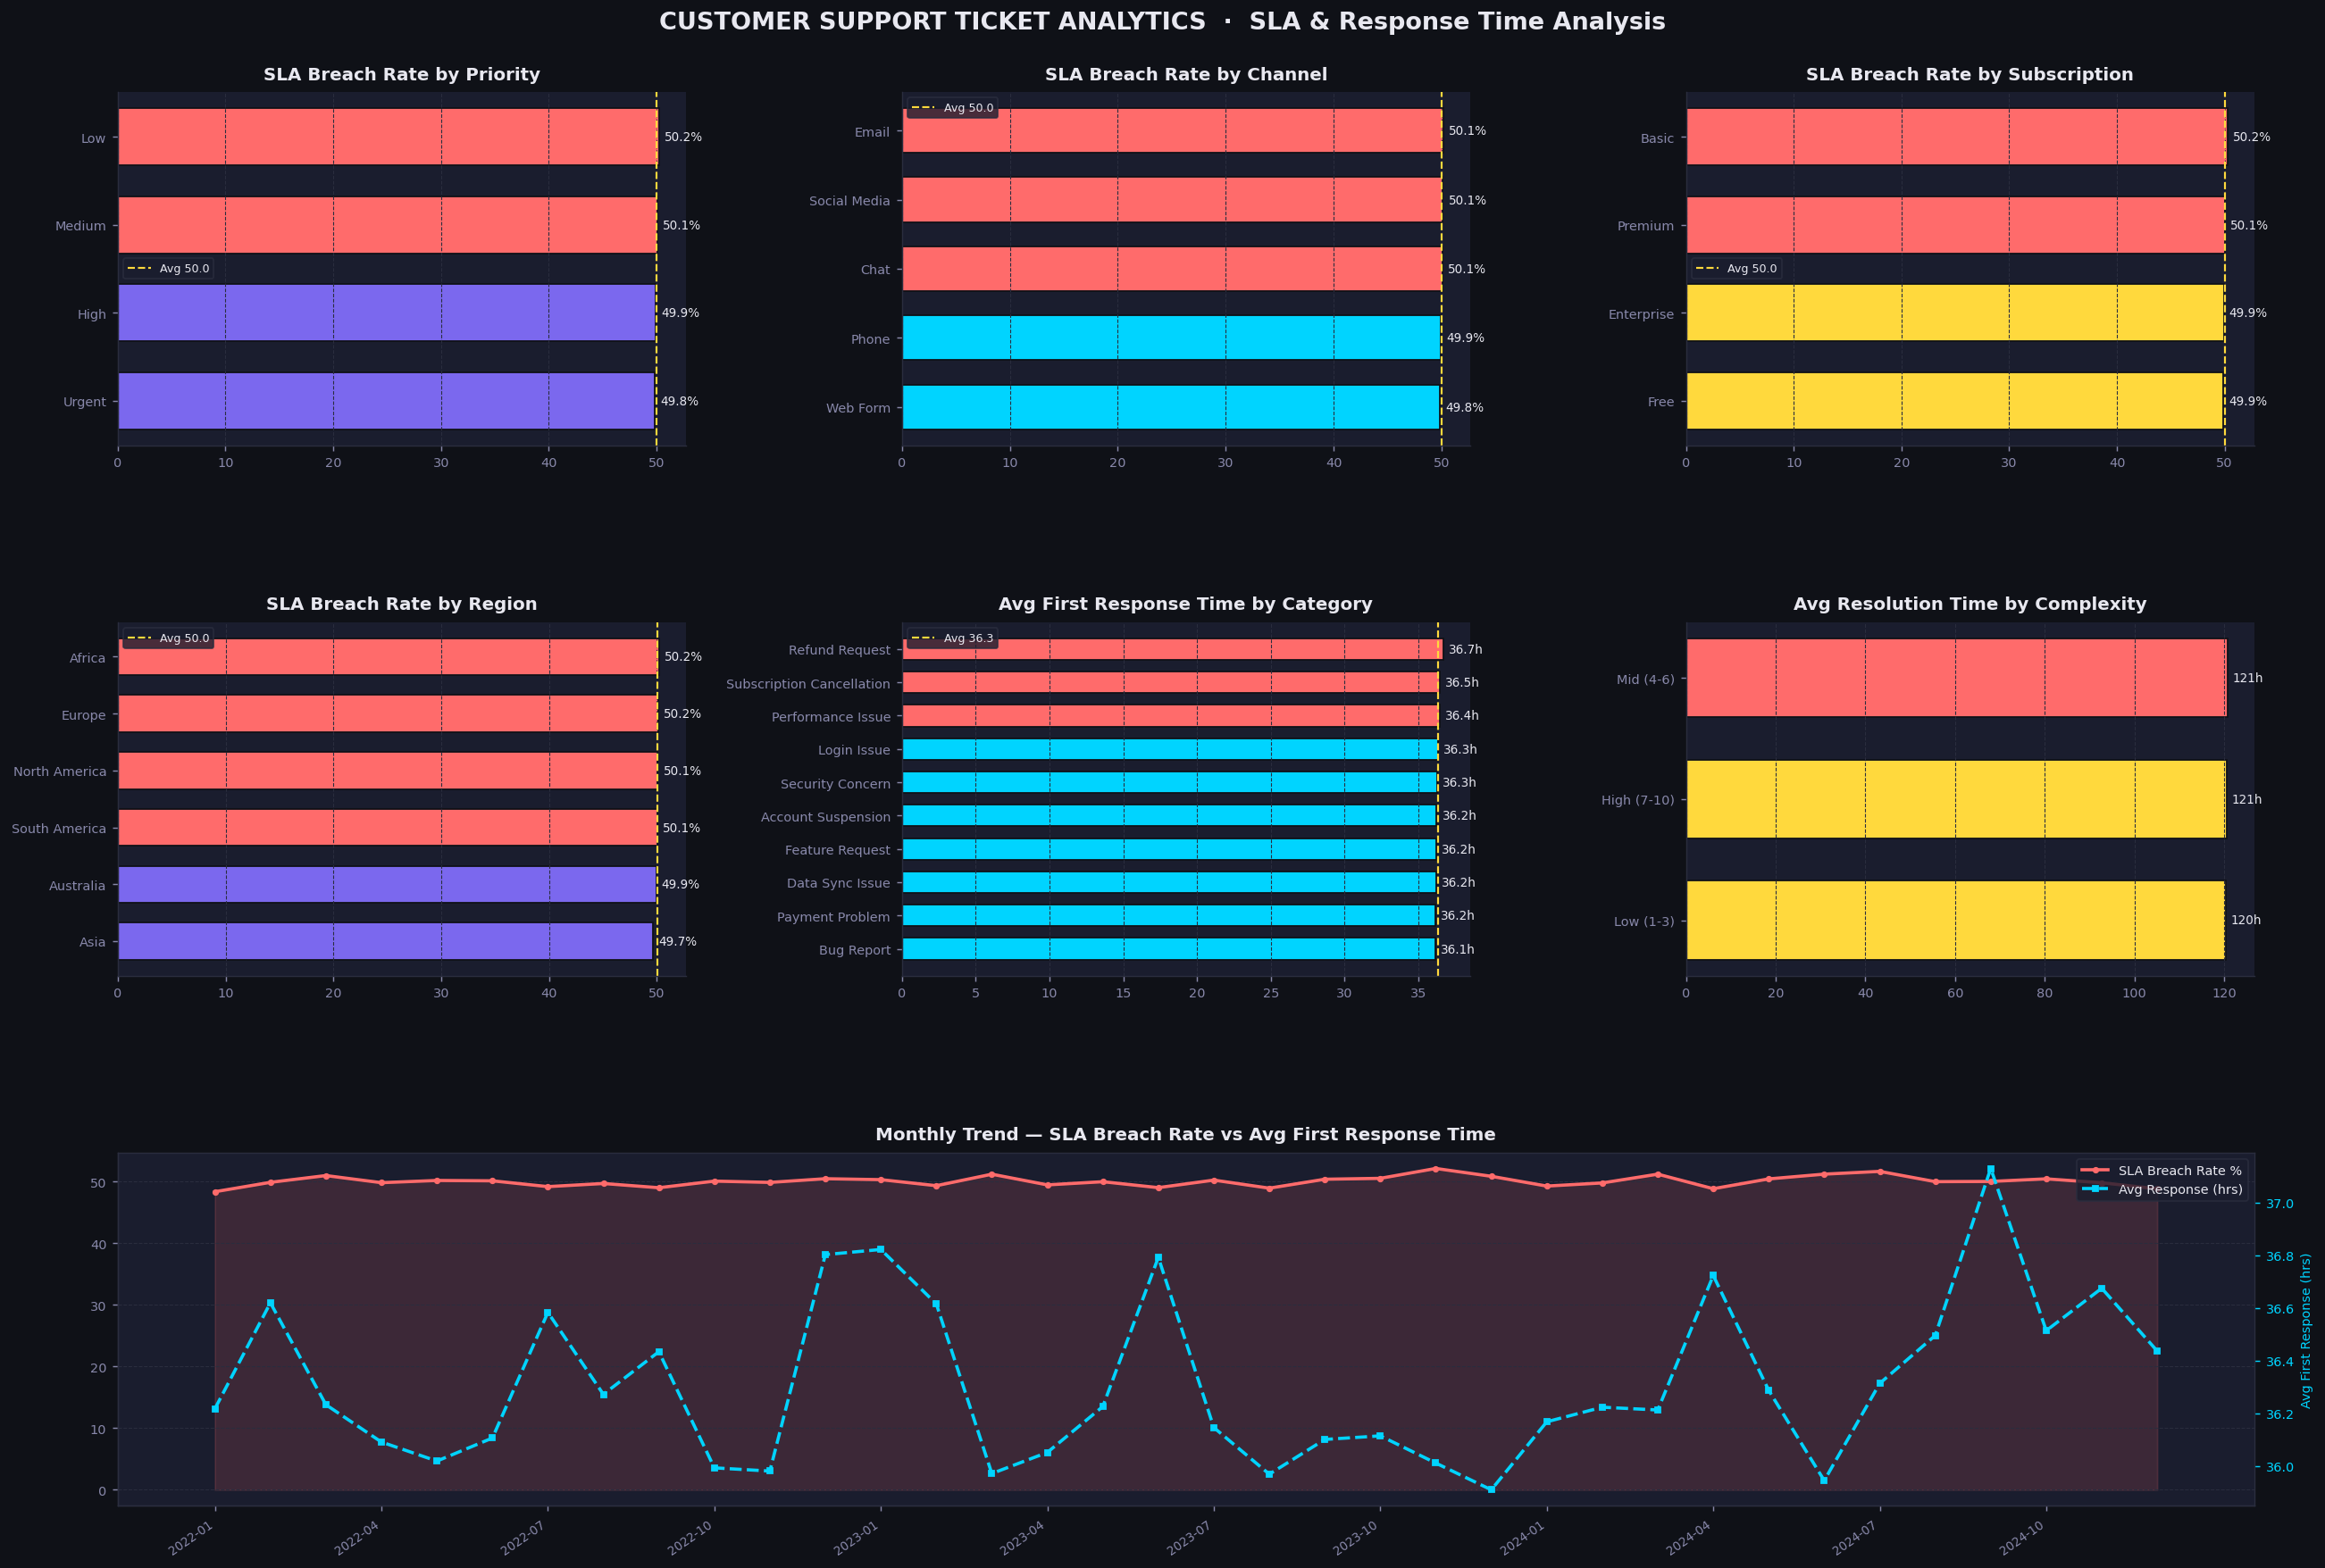

Page 2 saved ✓


In [8]:
# ── Pre-compute ─────────────────────────────────────────────────
sla_by_priority = df.groupby('priority')['sla_breached'].mean() * 100
sla_by_channel  = df.groupby('channel')['sla_breached'].mean() * 100
sla_by_category = df.groupby('category')['sla_breached'].mean() * 100
sla_by_region   = df.groupby('region')['sla_breached'].mean() * 100
sla_by_sub      = df.groupby('subscription_type')['sla_breached'].mean() * 100

avg_resp_by_cat  = df.groupby('category')['first_response_time_hours'].mean()
avg_res_by_compl = df.groupby('complexity_bucket', observed=True)['resolution_time_hours'].mean()

monthly_sla = df.groupby('year_month').agg(
    sla_breach_rate=('sla_breached','mean'),
    avg_response=('first_response_time_hours','mean')
).reset_index()
monthly_sla['ym_str'] = monthly_sla['year_month'].astype(str)

overall_breach = df['sla_breached'].mean() * 100

# ── Layout ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('CUSTOMER SUPPORT TICKET ANALYTICS  ·  SLA & Response Time Analysis',
             fontsize=15, fontweight='bold', color=TEXT, y=0.98)

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.50, wspace=0.38,
    top=0.93, bottom=0.06, left=0.05, right=0.97
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, :])

# SLA by priority
bar_h(ax1, sla_by_priority.sort_values(), 'SLA Breach Rate by Priority',
      color=ACCENT1, fmt=lambda v: f'{v:.1f}%', avg_line=overall_breach)

# SLA by channel
bar_h(ax2, sla_by_channel.sort_values(), 'SLA Breach Rate by Channel',
      color=ACCENT2, fmt=lambda v: f'{v:.1f}%', avg_line=overall_breach)

# SLA by subscription
bar_h(ax3, sla_by_sub.sort_values(), 'SLA Breach Rate by Subscription',
      color=ACCENT5, fmt=lambda v: f'{v:.1f}%', avg_line=overall_breach)

# SLA by region
bar_h(ax4, sla_by_region.sort_values(), 'SLA Breach Rate by Region',
      color=ACCENT1, fmt=lambda v: f'{v:.1f}%', avg_line=overall_breach)

# Avg response time by category
bar_h(ax5, avg_resp_by_cat.sort_values(), 'Avg First Response Time by Category',
      color=ACCENT2, fmt=lambda v: f'{v:.1f}h', avg_line=avg_resp_by_cat.mean())

# Avg resolution by complexity
bar_h(ax6, avg_res_by_compl.sort_values(), 'Avg Resolution Time by Complexity',
      color=ACCENT5, fmt=lambda v: f'{v:.0f}h')

# Monthly SLA breach + avg response trend (dual axis)
x = range(len(monthly_sla))
ax7b = ax7.twinx()
ax7.fill_between(x, monthly_sla['sla_breach_rate']*100, alpha=0.15, color=ACCENT3)
ax7.plot(x, monthly_sla['sla_breach_rate']*100, color=ACCENT3, linewidth=2,
         marker='o', markersize=3, label='SLA Breach Rate %')
ax7b.plot(x, monthly_sla['avg_response'], color=ACCENT2, linewidth=2,
          linestyle='--', marker='s', markersize=3, label='Avg Response (hrs)')
ax7.set_xticks(list(x)[::step])
ax7.set_xticklabels(monthly_sla['ym_str'].iloc[::step], rotation=35, ha='right', fontsize=7.5)
ax7.set_ylabel('Breach Rate (%)', color=ACCENT3, fontsize=8)
ax7b.set_ylabel('Avg First Response (hrs)', color=ACCENT2, fontsize=8)
ax7b.tick_params(colors=ACCENT2)
ax7b.spines[['top','right']].set_color(GRID)
lines1, labels1 = ax7.get_legend_handles_labels()
lines2, labels2 = ax7b.get_legend_handles_labels()
ax7.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=8)
style_ax(ax7, title='Monthly Trend — SLA Breach Rate vs Avg First Response Time', grid_axis='y')

plt.show()
print('Page 2 saved ✓')

---
## PAGE 3 — Escalation & Risk Analysis

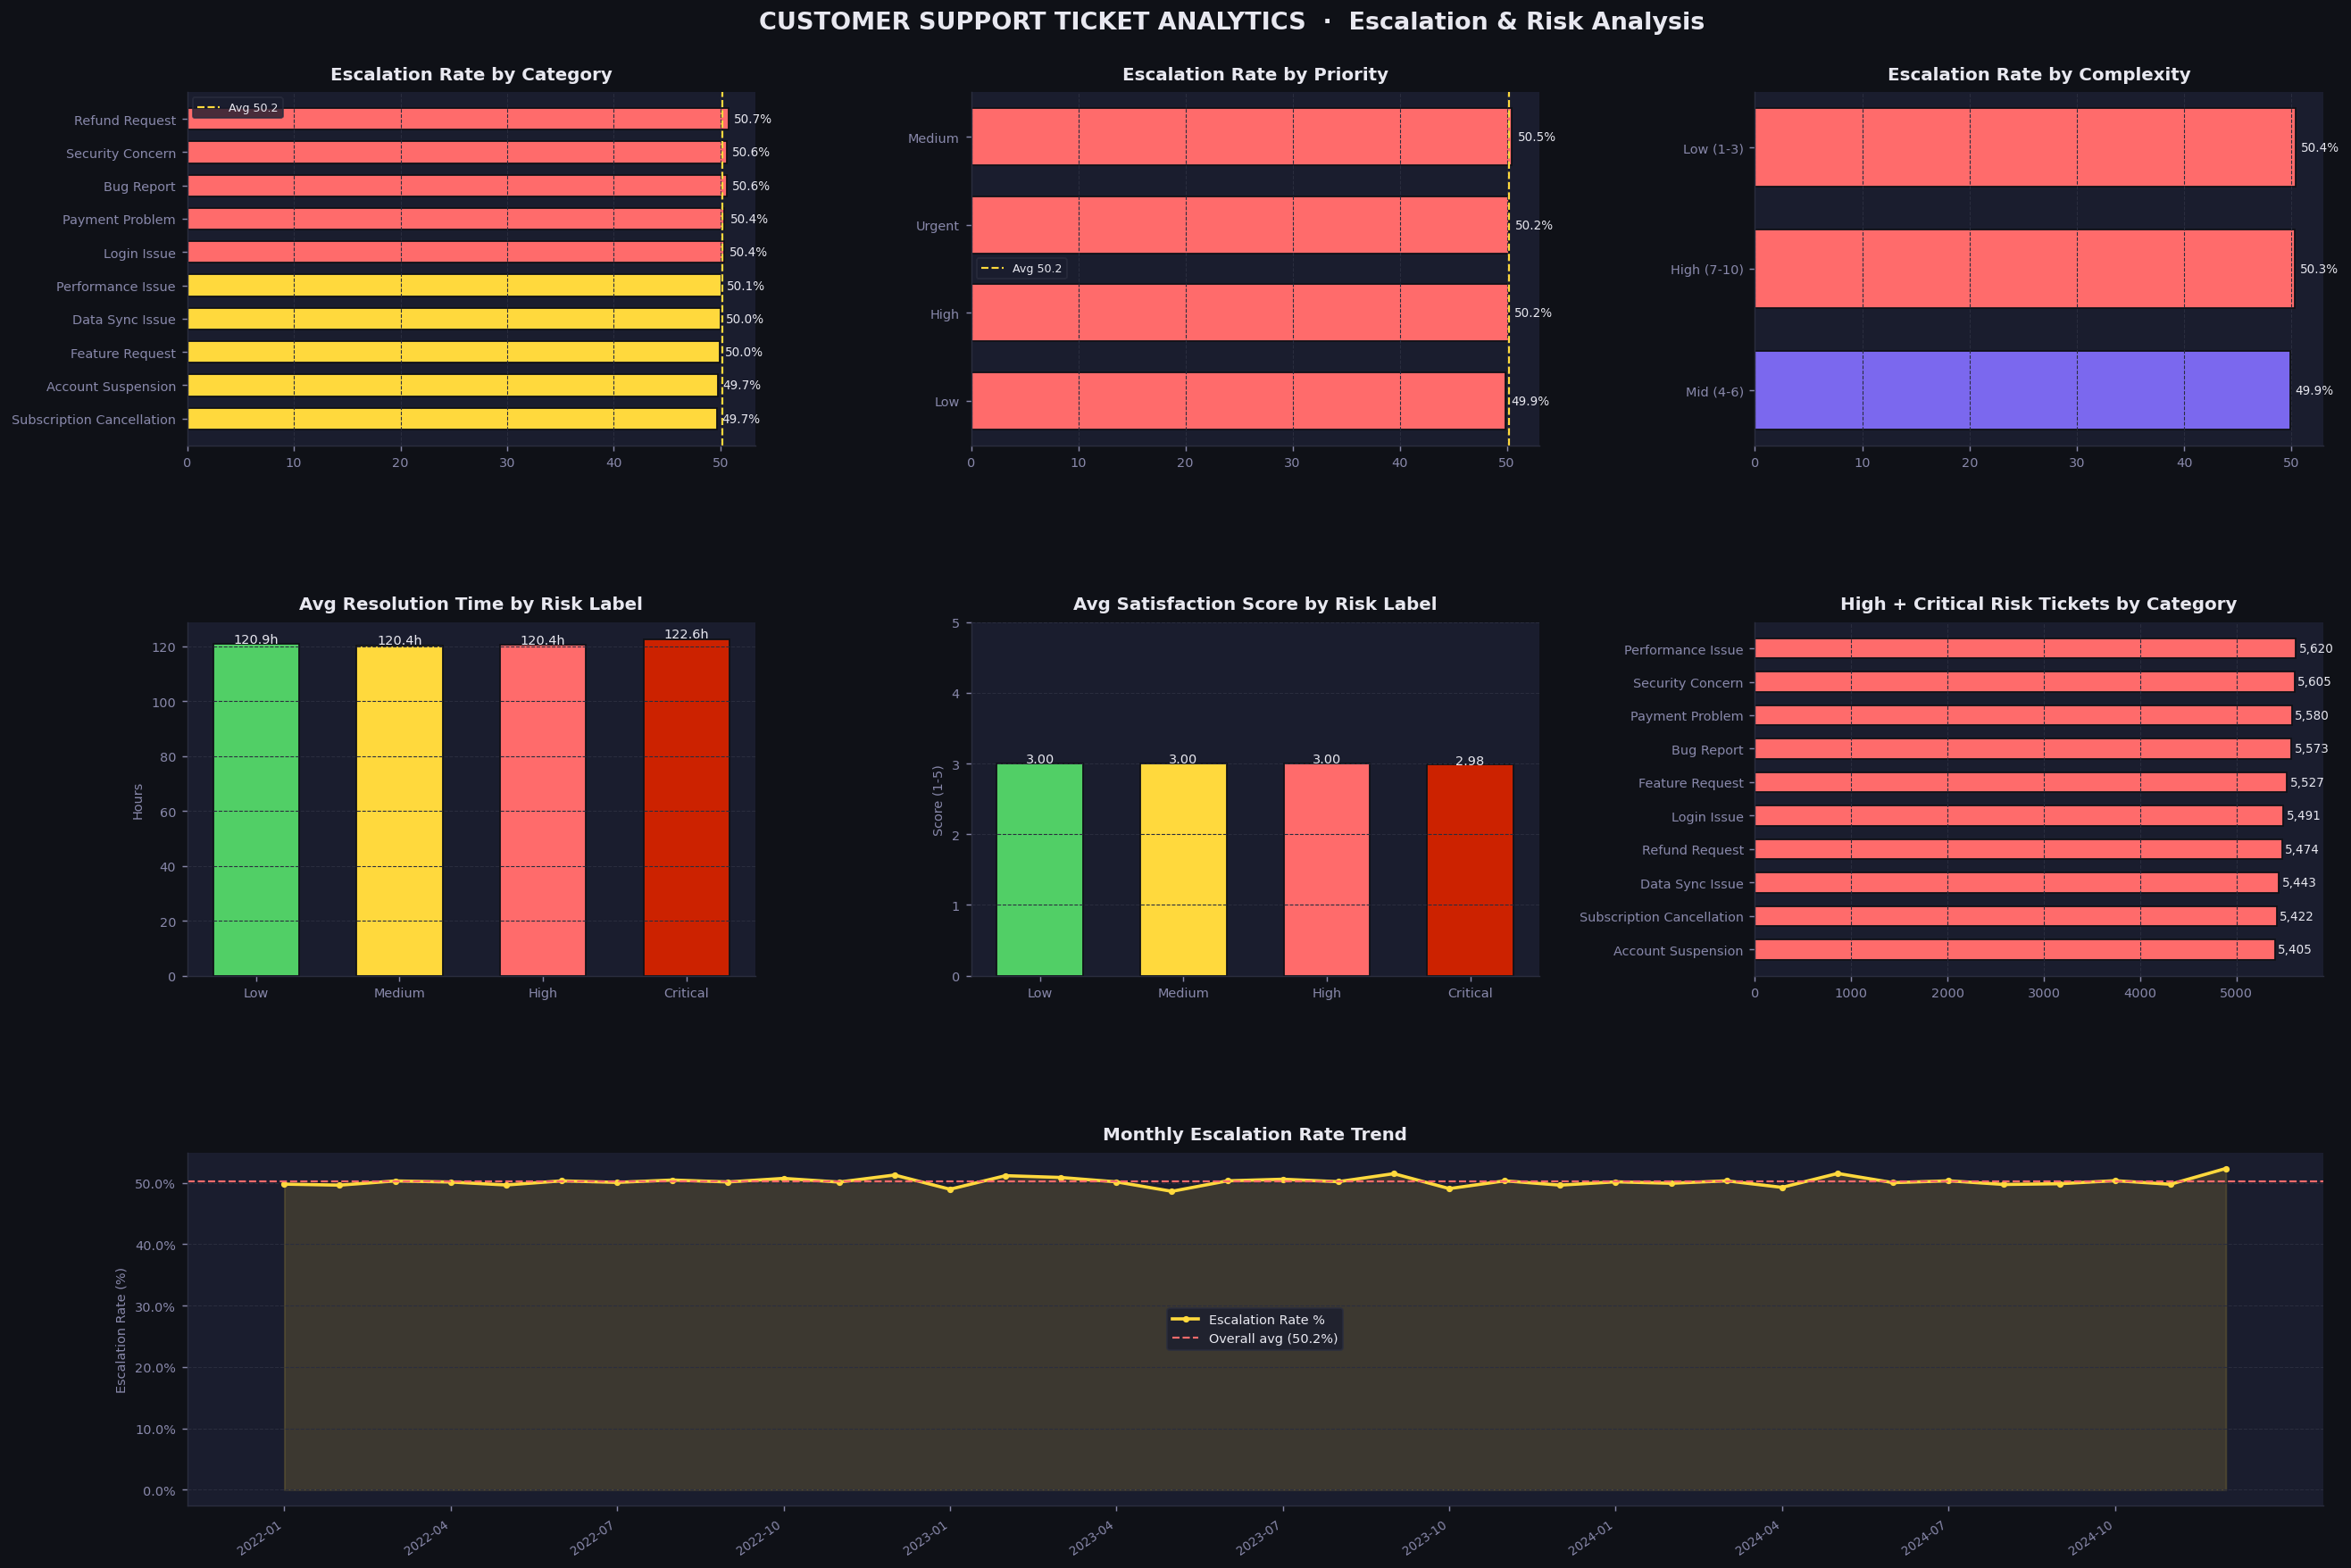

Page 3 saved ✓


In [10]:
# ── Pre-compute ─────────────────────────────────────────────────
esc_by_cat    = df.groupby('category')['escalated'].mean() * 100
esc_by_prio   = df.groupby('priority')['escalated'].mean() * 100
esc_by_compl  = df.groupby('complexity_bucket', observed=True)['escalated'].mean() * 100
esc_by_sub    = df.groupby('subscription_type')['escalated'].mean() * 100

risk_res_time = df.groupby('risk_label')['resolution_time_hours'].mean().reindex(['Low','Medium','High','Critical'])
risk_sat      = df.groupby('risk_label')['customer_satisfaction_score'].mean().reindex(['Low','Medium','High','Critical'])

# Escalated vs Not — comparison
esc_comp = df.groupby('escalated').agg(
    avg_response=('first_response_time_hours','mean'),
    avg_resolution=('resolution_time_hours','mean'),
    sla_rate=('sla_breached','mean'),
    satisfaction=('customer_satisfaction_score','mean')
).round(2)
esc_comp.index = ['Not Escalated','Escalated']

# Risk ticket count by category
risk_cat = df[df['risk_label'].isin(['High','Critical'])].groupby('category').size().sort_values(ascending=True)

monthly_esc = df.groupby('year_month')['escalated'].mean().reset_index()
monthly_esc['ym_str'] = monthly_esc['year_month'].astype(str)

# ── Layout ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('CUSTOMER SUPPORT TICKET ANALYTICS  ·  Escalation & Risk Analysis',
             fontsize=15, fontweight='bold', color=TEXT, y=0.98)

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.50, wspace=0.38,
    top=0.93, bottom=0.06, left=0.05, right=0.97
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, :])

# Escalation by category
bar_h(ax1, esc_by_cat.sort_values(), 'Escalation Rate by Category',
      color=ACCENT5, fmt=lambda v: f'{v:.1f}%', avg_line=df['escalated'].mean()*100)

# Escalation by priority
bar_h(ax2, esc_by_prio.sort_values(), 'Escalation Rate by Priority',
      color=ACCENT3, fmt=lambda v: f'{v:.1f}%', avg_line=df['escalated'].mean()*100)

# Escalation by complexity
bar_h(ax3, esc_by_compl.sort_values(), 'Escalation Rate by Complexity',
      color=ACCENT1, fmt=lambda v: f'{v:.1f}%')

# Risk label vs resolution time
risk_colors = [ACCENT4, ACCENT5, ACCENT3, '#CC2200']
ax4.bar(risk_res_time.index, risk_res_time.values,
        color=risk_colors[:len(risk_res_time)], edgecolor=BG, width=0.6)
for i, v in enumerate(risk_res_time.values):
    ax4.text(i, v + 0.5, f'{v:.1f}h', ha='center', fontsize=8, color=TEXT)
style_ax(ax4, title='Avg Resolution Time by Risk Label', ylabel='Hours', grid_axis='y')

# Risk label vs satisfaction
ax5.bar(risk_sat.index, risk_sat.values,
        color=risk_colors[:len(risk_sat)], edgecolor=BG, width=0.6)
for i, v in enumerate(risk_sat.values):
    ax5.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8, color=TEXT)
style_ax(ax5, title='Avg Satisfaction Score by Risk Label', ylabel='Score (1-5)', grid_axis='y')
ax5.set_ylim(0, 5)

# High+Critical risk tickets by category
ax6.barh(risk_cat.index, risk_cat.values, color=ACCENT3, edgecolor=BG, height=0.6)
for i, v in enumerate(risk_cat.values):
    ax6.text(v + 30, i, f'{v:,}', va='center', fontsize=7.5, color=TEXT)
style_ax(ax6, title='High + Critical Risk Tickets by Category', grid_axis='x')

# Monthly escalation trend
x7 = range(len(monthly_esc))
ax7.fill_between(x7, monthly_esc['escalated']*100, alpha=0.15, color=ACCENT5)
ax7.plot(x7, monthly_esc['escalated']*100, color=ACCENT5, linewidth=2,
         marker='o', markersize=3, label='Escalation Rate %')
ax7.axhline(df['escalated'].mean()*100, color=ACCENT3, linestyle='--',
            linewidth=1.2, label=f'Overall avg ({df["escalated"].mean()*100:.1f}%)')
ax7.set_xticks(list(x7)[::step])
ax7.set_xticklabels(monthly_esc['ym_str'].iloc[::step], rotation=35, ha='right', fontsize=7.5)
ax7.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=1))
ax7.legend(fontsize=8)
style_ax(ax7, title='Monthly Escalation Rate Trend', ylabel='Escalation Rate (%)', grid_axis='y')

plt.show()
print('Page 3 saved ✓')

---
## PAGE 4 — Category & Channel Performance

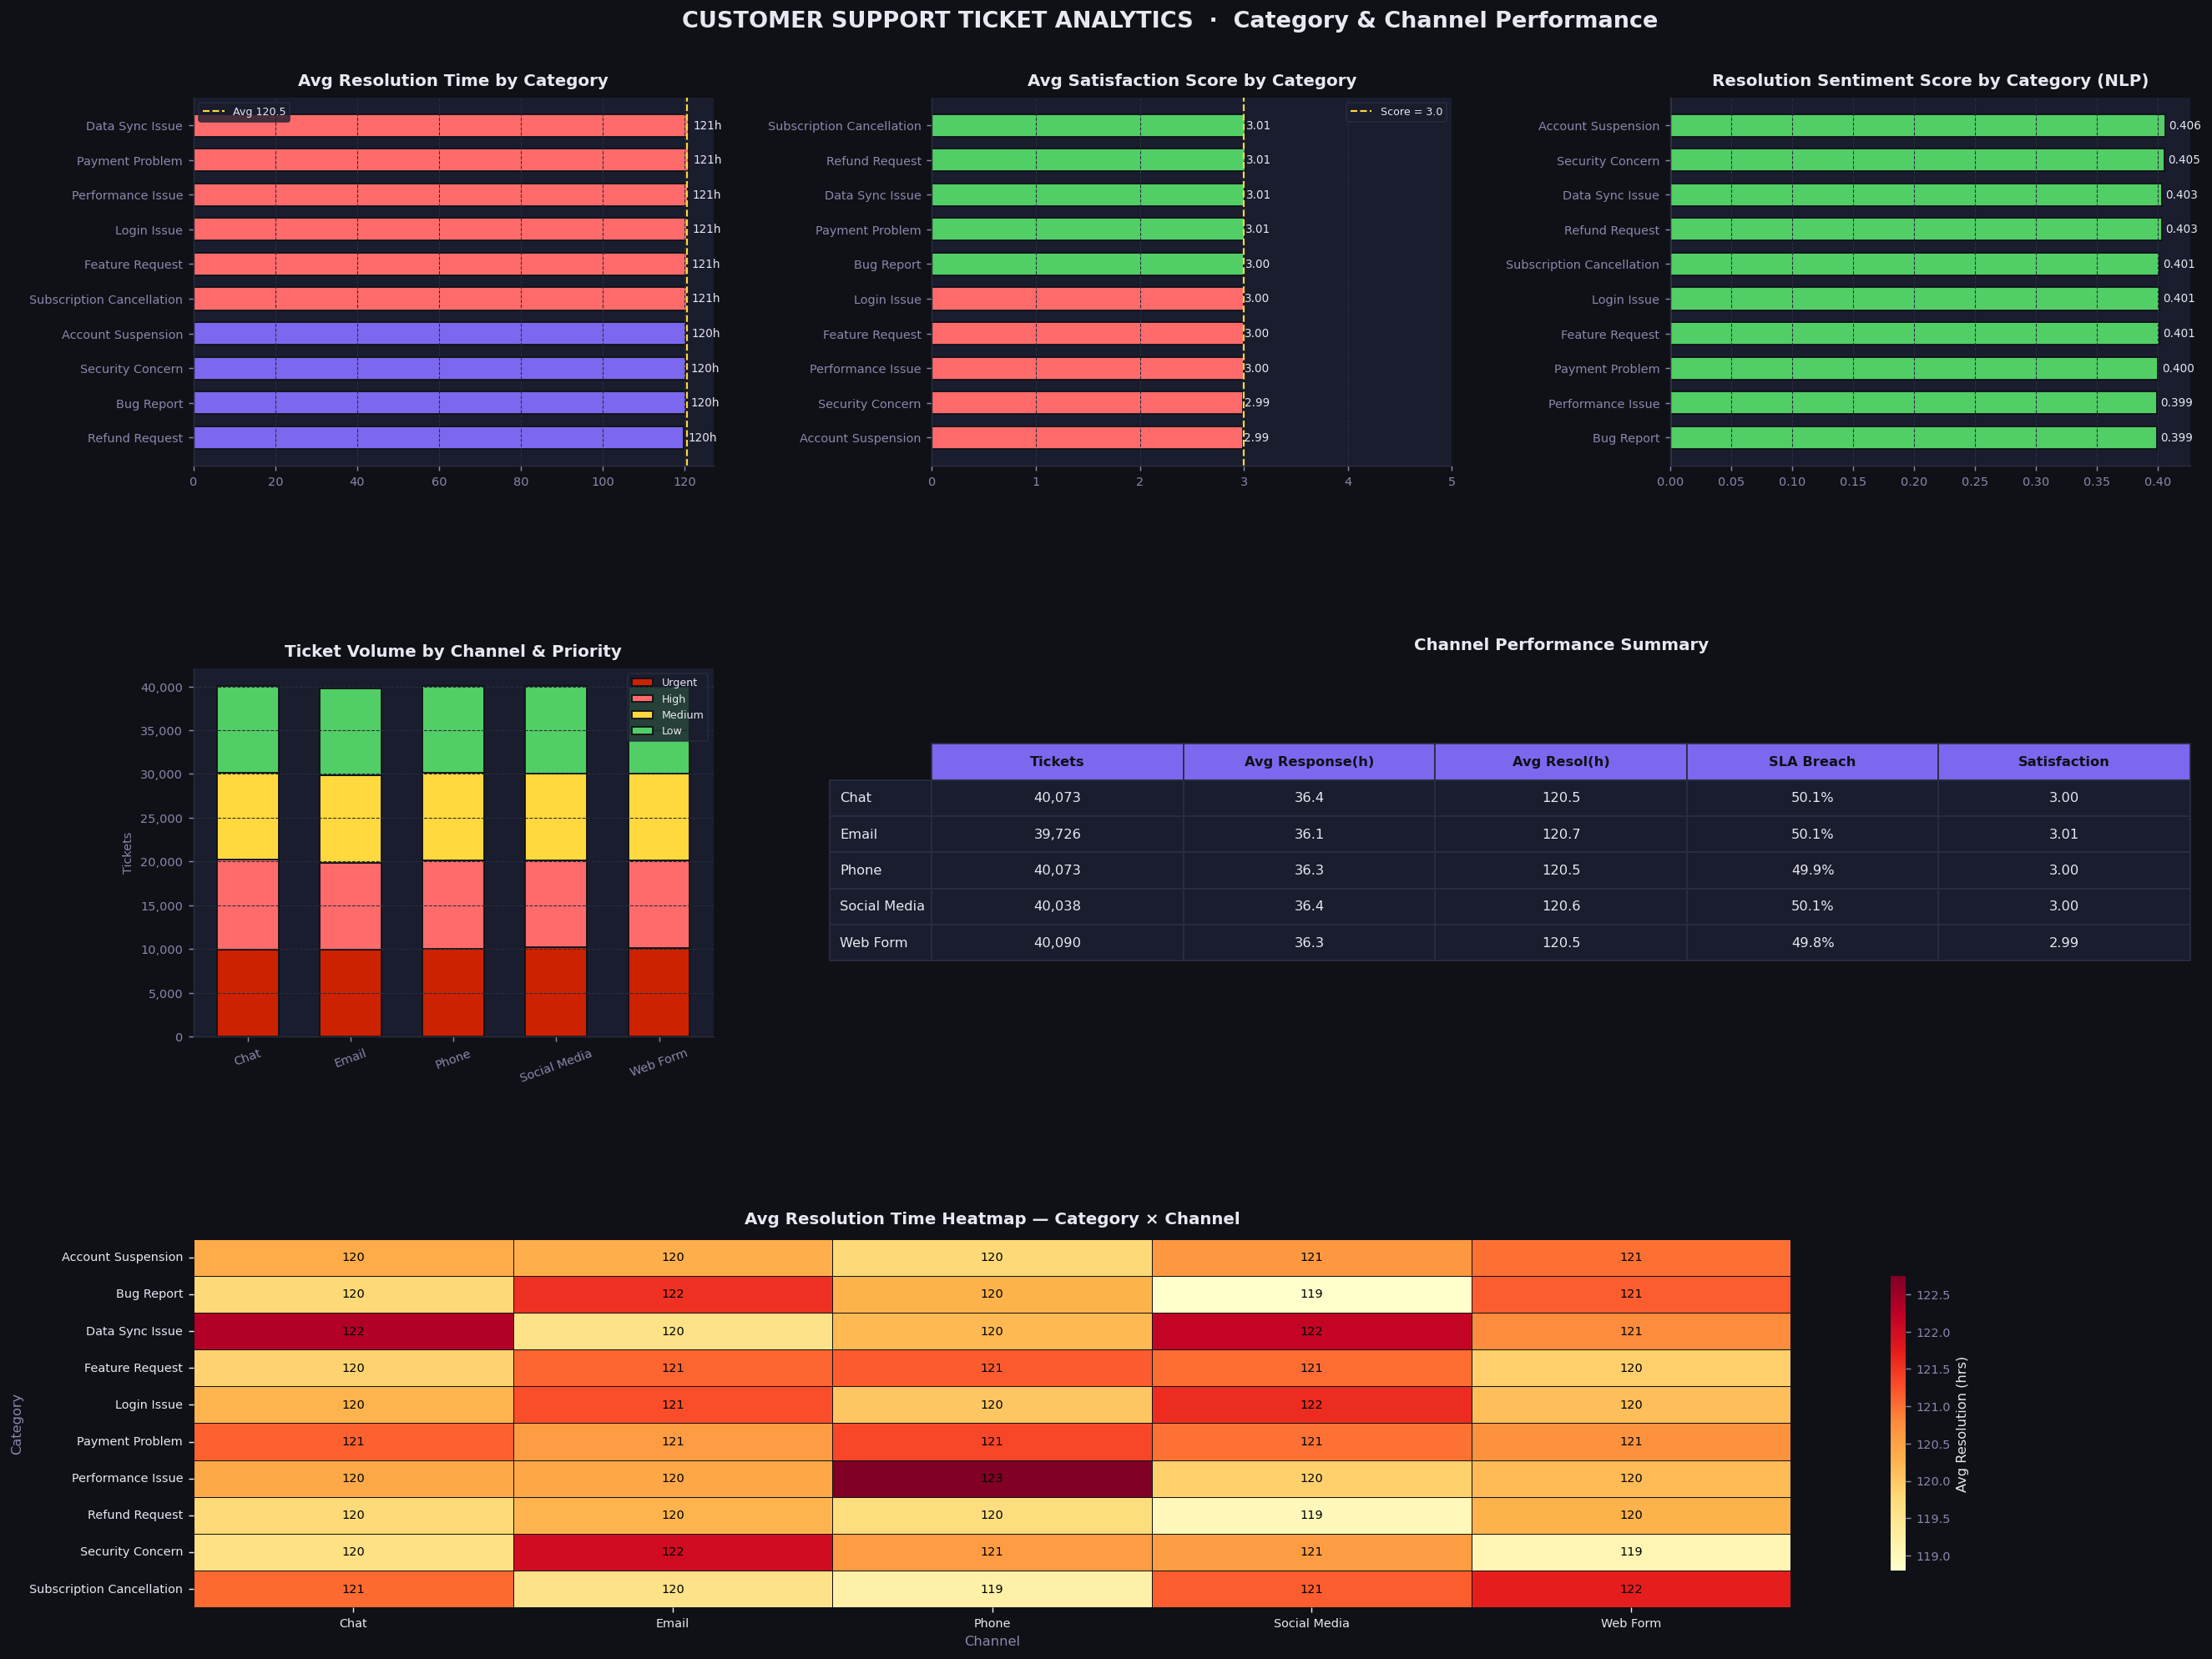

Page 4 saved ✓


In [12]:
# ── Pre-compute ─────────────────────────────────────────────────
cat_metrics = df.groupby('category').agg(
    tickets=('ticket_id','count'),
    avg_response=('first_response_time_hours','mean'),
    avg_resolution=('resolution_time_hours','mean'),
    sla_breach=('sla_breached','mean'),
    satisfaction=('customer_satisfaction_score','mean'),
    escalation=('escalated','mean'),
    avg_sentiment=('resolution_sentiment_score','mean')
).round(3)

chan_metrics = df.groupby('channel').agg(
    tickets=('ticket_id','count'),
    avg_response=('first_response_time_hours','mean'),
    avg_resolution=('resolution_time_hours','mean'),
    sla_breach=('sla_breached','mean'),
    satisfaction=('customer_satisfaction_score','mean')
).round(3)

# Satisfaction by category
sat_by_cat = cat_metrics['satisfaction'].sort_values()

# Resolution sentiment from Phase 2 NLP
sent_by_cat = cat_metrics['avg_sentiment'].sort_values()

# Channel volume stacked by priority
chan_prio = df.groupby(['channel','priority']).size().unstack(fill_value=0)
chan_prio = chan_prio[['Urgent','High','Medium','Low']]

# Heatmap: category x channel = avg resolution
heatmap_data = df.groupby(['category','channel'])['resolution_time_hours'].mean().unstack()

# ── Layout ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16), facecolor=BG)
fig.suptitle('CUSTOMER SUPPORT TICKET ANALYTICS  ·  Category & Channel Performance',
             fontsize=15, fontweight='bold', color=TEXT, y=0.98)

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.55, wspace=0.42,
    top=0.93, bottom=0.06, left=0.05, right=0.97
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1:3])
ax6 = fig.add_subplot(gs[2, :])

# Avg resolution time by category
bar_h(ax1, cat_metrics['avg_resolution'].sort_values(),
      'Avg Resolution Time by Category',
      color=ACCENT1, fmt=lambda v: f'{v:.0f}h',
      avg_line=cat_metrics['avg_resolution'].mean())

# Satisfaction by category
colors_sat = [ACCENT4 if v >= 3.0 else ACCENT3 for v in sat_by_cat.values]
ax2.barh(sat_by_cat.index, sat_by_cat.values, color=colors_sat, edgecolor=BG, height=0.65)
ax2.axvline(3.0, color=ACCENT5, linestyle='--', linewidth=1.2, label='Score = 3.0')
for i, v in enumerate(sat_by_cat.values):
    ax2.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=7.5, color=TEXT)
ax2.set_xlim(0, 5)
ax2.legend(fontsize=7)
style_ax(ax2, title='Avg Satisfaction Score by Category', grid_axis='x')

# NLP resolution sentiment by category
colors_sent = [ACCENT4 if v >= 0 else ACCENT3 for v in sent_by_cat.values]
ax3.barh(sent_by_cat.index, sent_by_cat.values, color=colors_sent, edgecolor=BG, height=0.65)
ax3.axvline(0, color=SUBTEXT, linewidth=0.8)
for i, v in enumerate(sent_by_cat.values):
    offset = 0.003 if v >= 0 else -0.003
    ha = 'left' if v >= 0 else 'right'
    ax3.text(v + offset, i, f'{v:.3f}', va='center', ha=ha, fontsize=7.5, color=TEXT)
style_ax(ax3, title='Resolution Sentiment Score by Category (NLP)', grid_axis='x')

# Channel volume by priority (stacked bar)
prio_colors = ['#CC2200', ACCENT3, ACCENT5, ACCENT4]
bottom = np.zeros(len(chan_prio))
for col, col_c in zip(chan_prio.columns, prio_colors):
    ax4.bar(chan_prio.index, chan_prio[col], bottom=bottom,
            label=col, color=col_c, edgecolor=BG, width=0.6)
    bottom += chan_prio[col].values
ax4.legend(fontsize=7, loc='upper right')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
style_ax(ax4, title='Ticket Volume by Channel & Priority', ylabel='Tickets', grid_axis='y')
ax4.tick_params(axis='x', rotation=20)

# Channel metrics table
ax5.axis('off')
ax5.set_facecolor(PANEL)
table_data = chan_metrics.copy()
table_data.columns = ['Tickets','Avg Response(h)','Avg Resol(h)','SLA Breach','Satisfaction']
table_data['Tickets']        = table_data['Tickets'].apply(lambda v: f'{int(v):,}')
table_data['Avg Response(h)']= table_data['Avg Response(h)'].apply(lambda v: f'{v:.1f}')
table_data['Avg Resol(h)']   = table_data['Avg Resol(h)'].apply(lambda v: f'{v:.1f}')
table_data['SLA Breach']     = table_data['SLA Breach'].apply(lambda v: f'{v*100:.1f}%')
table_data['Satisfaction']   = table_data['Satisfaction'].apply(lambda v: f'{v:.2f}')

tbl = ax5.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    rowLabels=table_data.index,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.0)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor(PANEL if r > 0 else ACCENT1)
    cell.set_text_props(color=TEXT if r > 0 else BG, fontweight='normal' if r > 0 else 'bold')
    cell.set_edgecolor(GRID)
ax5.set_title('Channel Performance Summary', color=TEXT, fontsize=11,
              fontweight='bold', pad=12)

# Heatmap: avg resolution time — category x channel
sns.heatmap(
    heatmap_data, ax=ax6, cmap='YlOrRd',
    annot=True, fmt='.0f', annot_kws={'size': 8, 'color': 'black'},
    linewidths=0.5, linecolor=BG,
    cbar_kws={'label': 'Avg Resolution (hrs)', 'shrink': 0.8}
)
ax6.set_title('Avg Resolution Time Heatmap — Category × Channel',
              color=TEXT, fontsize=11, fontweight='bold', pad=10)
ax6.set_xlabel('Channel', color=SUBTEXT, fontsize=9)
ax6.set_ylabel('Category', color=SUBTEXT, fontsize=9)
ax6.tick_params(colors=TEXT)

plt.savefig('dashboard_page4_performance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Page 4 saved ✓')

---
## All Pages Summary

In [13]:
pages = [
    'dashboard_page1_overview.png',
    'dashboard_page2_sla.png',
    'dashboard_page3_escalation.png',
    'dashboard_page4_performance.png',
]

print('=' * 55)
print('  DASHBOARD EXPORT COMPLETE')
print('=' * 55)
for p in pages:
    print(f'  ✓  {p}')
print('=' * 55)
print(f'\n  Dataset : 200,000 tickets  |  2022 – 2024')
print(f'  SLA Breach Rate  : {df["sla_breached"].mean():.1%}')
print(f'  Escalation Rate  : {df["escalated"].mean():.1%}')
print(f'  Avg Response     : {df["first_response_time_hours"].mean():.1f} hrs')
print(f'  Avg Resolution   : {df["resolution_time_hours"].mean():.1f} hrs  '
      f'({df["resolution_time_hours"].mean()/24:.1f} days)')
print(f'  Avg Satisfaction : {df["customer_satisfaction_score"].mean():.2f} / 5')

  DASHBOARD EXPORT COMPLETE
  ✓  dashboard_page1_overview.png
  ✓  dashboard_page2_sla.png
  ✓  dashboard_page3_escalation.png
  ✓  dashboard_page4_performance.png

  Dataset : 200,000 tickets  |  2022 – 2024
  SLA Breach Rate  : 50.0%
  Escalation Rate  : 50.2%
  Avg Response     : 36.3 hrs
  Avg Resolution   : 120.5 hrs  (5.0 days)
  Avg Satisfaction : 3.00 / 5
